# Proyecto Final UD2
#### UD2. Aprendizaxe Supervisada
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo), Vanesa Resúa Eiras, Cristina Gómez Alonso

En este proyecto, los alumnos del módulo de Machine Learning deberán demostrar los conocimientos adquiridos durante la UD2 y aplicar al menos dos algoritmos diferentes de aprendizaje supervisado vistos en clase (KNN, Regresión Lineal, Regresión Logística, Árboles de Decisión (o Randm Forest), SVM).

Para ello, tomaremos como referencia el dataset credit_train.csv y credit_test.csv que contienen la información sobre una campaña de márketing llevada a cabo mediante llamadas teléfonicas para captar clientes que quieran acceder a un crédito.

**Features o Input variables:**

1 - age: edad numérica

2 - job : tipo de trabajo (puede tomar los valores: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')

3 - marital : estado civil (puede tomar los valores: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)

4 - education : nivel de estudios (puede tomar los valores: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')

5 - default: ya tiene un crédito solicitado por defecto? (puede tomar los valores: 'no','yes','unknown')

6 - housing: tiene hipoteca? (puede tomar los valores: 'no','yes','unknown')

7 - loan: tiene una cuenta personal? (puede tomar los valores: 'no','yes','unknown')

8 - contact: tipo de comunicación de contacto (puede tomar los valores: 'cellular','telephone')

9 - month: último mes de contacto (puede tomar los valores: 'jan', 'feb', 'mar', ..., 'nov', 'dec')

10 - day_of_week: último día de la semana en el que se le ha contactado (puede tomar los valores: 'mon','tue','wed','thu','fri')

11 - duration: duración del último contacto en segundos (numérico). Importante: este atributo afecta en gran medida a la salida ya que si duration es 0, entonces  la salida es 'no')

12 - campaign: número de veces que se le ha contactado durante la campaña a este cliente (numérico, incluye el último contacto)

13 - pdays: número de días que han pasado desde que el cliente fue contactado por última vez(numérico; 999 significa que no ha sido contactado anteriormente)

14 - previous: número de contactos anteriores a esta campaña a este cliente(numérico)

15 - poutcome: resultado de la última campaña de marketing (categorical: 'failure','nonexistent','success')

16 - emp.var.rate: employment variation rate - quarterly indicator (numérico)

17 - cons.price.idx: IPC - indicador mensual (numérico)

18 - cons.conf.idx: índice de confianza de los consumidores - indicador mensual (numérico)

19 - euribor3m: euribor tasa 3 meses - indicador diario (numérico)

20 - nr.employed: número de trabajadores - indicador en porciones  (numérico)

**Output variable (desired target):**

21 - y: Suscripción al crédito por parte del cliente? (binary: 'yes','no')

Los requisitos mínimos de este proyecto consisten en:

* Etapas comunes 1, 2 y 3 de importación, análisis numérico y visual, así como preprocesado.
* Para cada algoritmo que apliques deberás de mantener la siguiente estructura de 5 etapas (del 4-8), pero puedes añadir subapartados o etapas adicionales.
* En cada etapa se deben añadir explicaciones justificativas de lo que se quiere hacer, así como de los resultados obtenidos.
* Como resultado final, se deben contrastar los resultados obtenidos y comparar los algoritmos utilizados indicando claramente cual y porqué obtiene mejor resultados.

Cualificaciones:
- Uso de 2 algoritmos: cualificación máxima de 7 puntos
- Uso de 3 algoritmos: cualificación máxima de 10 puntos.




## 1. Importación de paquetes y dataset

Importación del dataset

In [1]:
# Importing Data Analysis Librarys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
warnings.filterwarnings('ignore')

In [2]:
credit = pd.read_csv("credit-train.csv")

credit_test = pd.read_csv("credit-test.csv")

## 2.EDA y Visual EDA

In [3]:
credit.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


Comprobamos si existen valores nulos (missing values) que requieran tratamiento y verificamos los tipos de datos de cada columna.

In [4]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [5]:
credit.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [6]:
credit.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

In [7]:
credit_test.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
dtype: int64

In [8]:
credit.duplicated().sum()

12

In [9]:
credit_test.duplicated().sum()

0

Analizamos la distribución de las variables numéricas y las relaciones entre ellas para detectar patrones o anomalías (outliers).

#### 2.1 Conocer las variables categóricas

Se examinan las categorías de las variables cualitativas para identificar su cardinalidad y evaluar el método de codificación más adecuado en fases posteriores.

In [10]:
print('Trabajos:\n', credit['job'].unique())

Trabajos:
 ['blue-collar' 'technician' 'management' 'services' 'retired' 'admin.'
 'housemaid' 'unemployed' 'entrepreneur' 'self-employed' 'unknown'
 'student']


In [11]:
print('Marital:\n', credit['marital'].unique())

Marital:
 ['married' 'single' 'divorced' 'unknown']


In [12]:
print('Education:\n', credit['education'].unique())

Education:
 ['basic.4y' 'unknown' 'university.degree' 'high.school' 'basic.9y'
 'professional.course' 'basic.6y' 'illiterate']


In [13]:
print('Default:\n', credit['default'].unique())
print('Housing:\n', credit['housing'].unique())
print('Loan:\n', credit['loan'].unique())

Default:
 ['unknown' 'no' 'yes']
Housing:
 ['yes' 'no' 'unknown']
Loan:
 ['no' 'yes' 'unknown']


#### 2.2 Conocer las variables numericas
Se estudia la distribución de las variables numéricas para detectar asimetrías, valores extremos y posibles transformaciones necesarias antes del modelado.

In [14]:
print('Min edad: ', credit['age'].max())
print('Max edad: ', credit['age'].min())
print('Valores Nulos: ', credit['age'].isnull().any())

Min edad:  98
Max edad:  17
Valores Nulos:  False


In [15]:

print('Min edad: ', credit['age'].max())
print('Max edad: ', credit['age'].min())
print('Valores Nulos: ', credit['age'].isnull().any())

Min edad:  98
Max edad:  17
Valores Nulos:  False


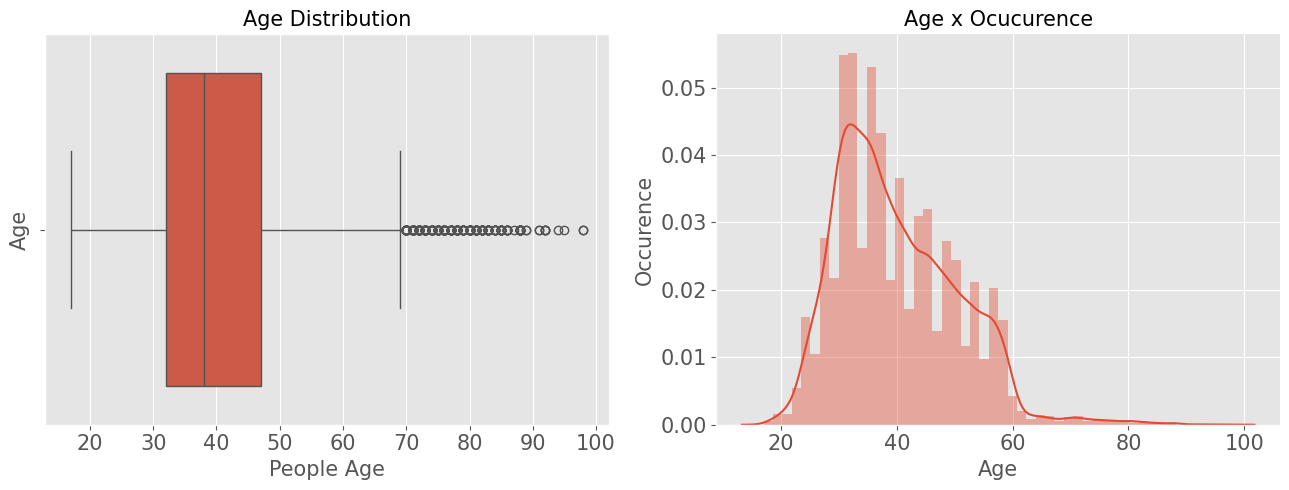

In [16]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (13, 5))
sns.boxplot(x = 'age', data = credit, orient = 'v', ax = ax1)
ax1.set_xlabel('People Age', fontsize=15)
ax1.set_ylabel('Age', fontsize=15)
ax1.set_title('Age Distribution', fontsize=15)
ax1.tick_params(labelsize=15)

sns.distplot(credit['age'], ax = ax2)
sns.despine(ax = ax2)
ax2.set_xlabel('Age', fontsize=15)
ax2.set_ylabel('Occurence', fontsize=15)
ax2.set_title('Age x Ocucurence', fontsize=15)
ax2.tick_params(labelsize=15)

plt.subplots_adjust(wspace=0.5)
plt.tight_layout() 

Se analiza la distribución de la edad para detectar posibles valores atípicos y comprobar si existe una relación evidente con la variable objetivo. La distribución es asimétrica, con mayor concentración en edades medias, y no se observan valores extremos que justifiquen su eliminación. A simple vista no se aprecia una relación fuerte con la variable objetivo, por lo que será el modelo el encargado de capturar posibles efectos no lineales.


In [17]:
# Quartiles
print('1º Quartil: ', credit['age'].quantile(q = 0.25))
print('2º Quartil: ', credit['age'].quantile(q = 0.50))
print('3º Quartil: ', credit['age'].quantile(q = 0.75))
print('4º Quartil: ', credit['age'].quantile(q = 1.00))
    
print('Ages above: ', credit['age'].quantile(q = 0.75) + 
                      1.5*(credit['age'].quantile(q = 0.75) - credit['age'].quantile(q = 0.25)), 'are outliers')

1º Quartil:  32.0
2º Quartil:  38.0
3º Quartil:  47.0
4º Quartil:  98.0
Ages above:  69.5 are outliers


In [18]:
print('Numerber of outliers: ', credit[credit['age'] > 69.6]['age'].count())
print('Number of clients: ', len(credit))
#Outliers in %
print('Outliers are:', round(credit[credit['age'] > 69.6]['age'].count()*100/len(credit),2), '%')

Numerber of outliers:  469
Number of clients:  41188
Outliers are: 1.14 %


In [19]:
print('MEAN:', round(credit['age'].mean(), 1))

print('STD :', round(credit['age'].std(), 1))

print('CV  :',round(credit['age'].std()*100/credit['age'].mean(), 1), ', High middle dispersion')

MEAN: 40.0
STD : 10.4
CV  : 26.0 , High middle dispersion


#### 2.3 JOBS

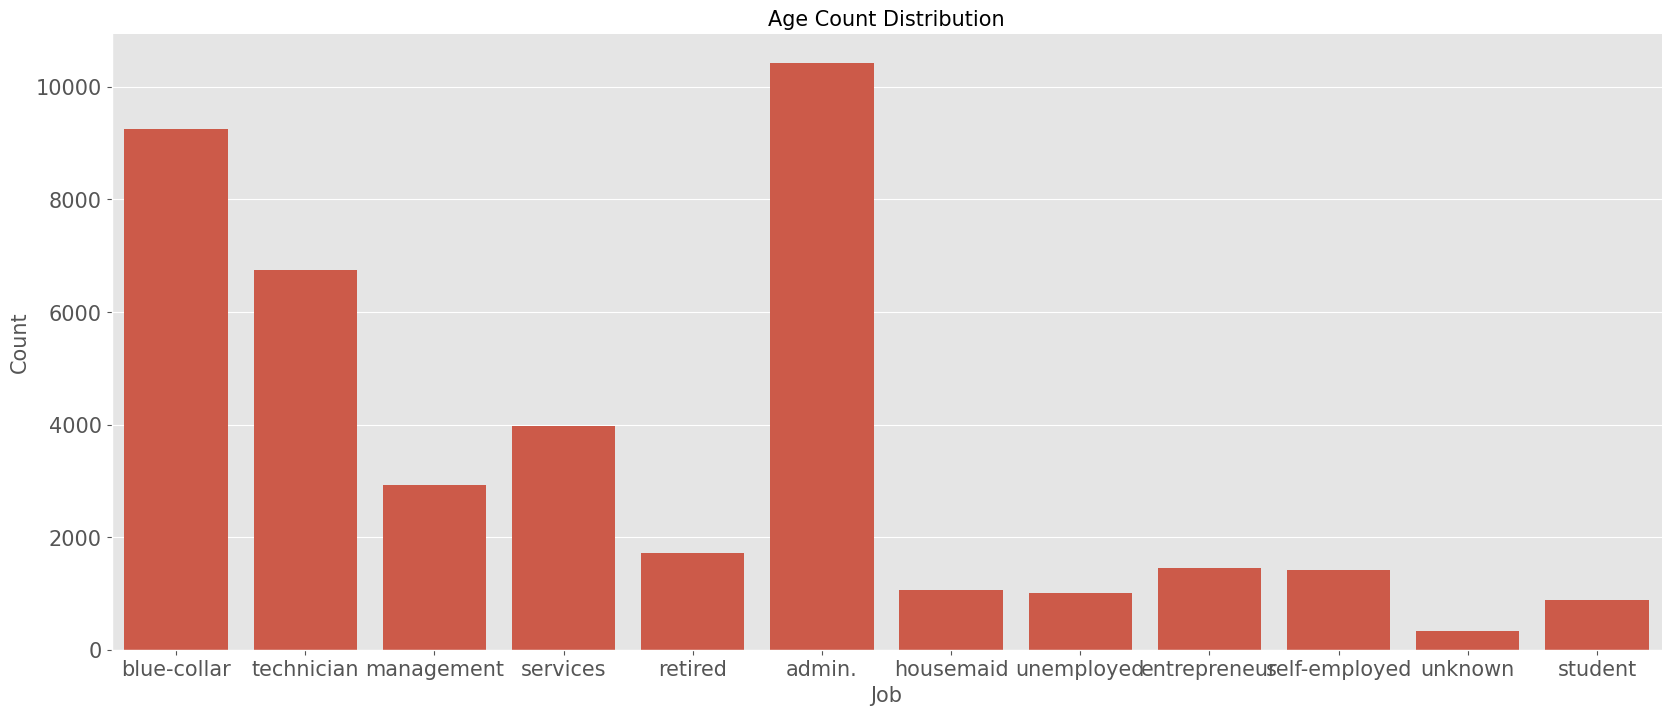

In [20]:
# Qué tipo de trabajos tienen los clientes de este banco;
fig, ax = plt.subplots()
fig.set_size_inches(20, 8)
sns.countplot(x = 'job', data = credit)
ax.set_xlabel('Job', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Age Count Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

Se estudia la relación entre el tipo de trabajo y la variable objetivo para identificar posibles segmentos con mayor tasa de conversión. Se observan diferencias claras entre categorías, lo que indica que esta variable contiene información relevante para el modelo y justifica su inclusión tras un proceso adecuado de codificación.

#### 2.4 MARITAL

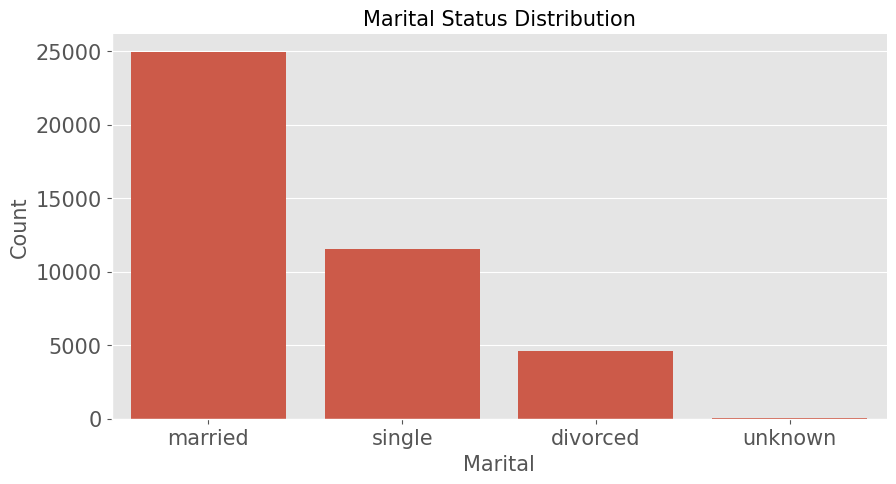

In [21]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 5)
sns.countplot(x = 'marital', data = credit)
ax.set_xlabel('Marital', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Marital Status Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

La gran mayoría son casados (aprox. 25,000), superando por más del doble a los solteros. Esto suele indicar clientes con mayor estabilidad, pero también con más cargas familiares.

#### 2.5 EDUCATION¶

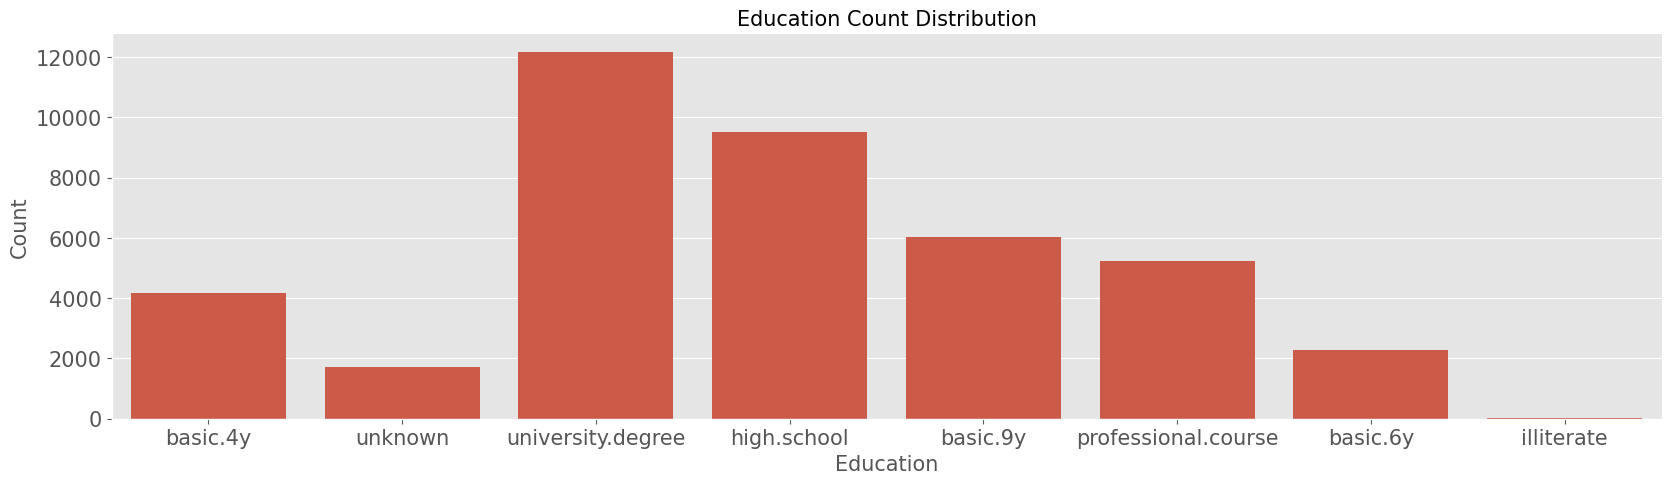

In [22]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 5)
sns.countplot(x = 'education', data = credit)
ax.set_xlabel('Education', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Education Count Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

El dataset tiene un sesgo claro hacia la educación superior. La categoría university.degree es la más frecuente, seguida de high.school.
Combinado con el gráfico anterior (mayoría casados), esto refuerza la idea de un perfil de cliente de clase media/estable.

#### 2.6. DEFAULT, HOUSING, LOAN

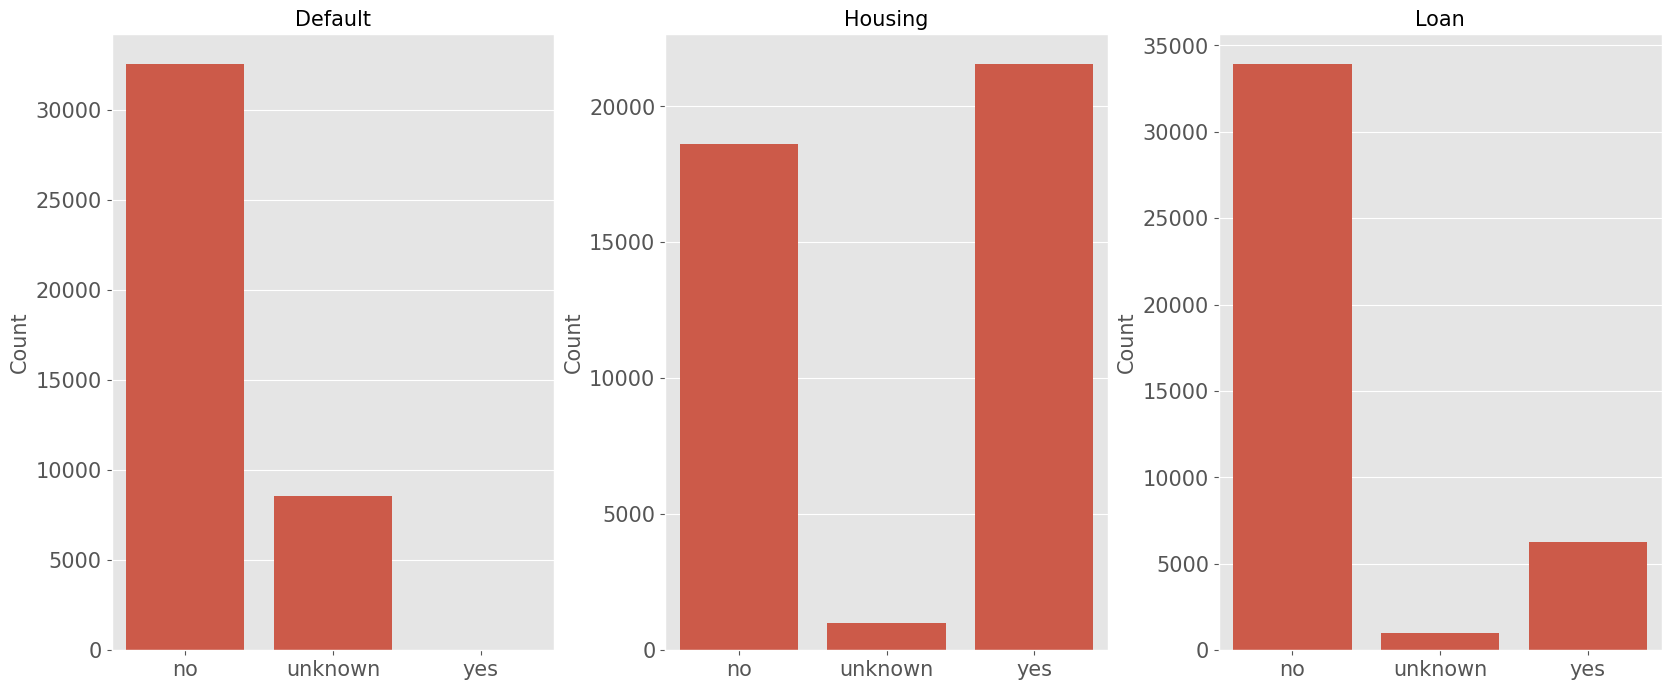

In [23]:
# Default: tiene crédito en incumplimiento?
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20,8))
sns.countplot(x='default', data=credit, ax=ax1, order=['no', 'unknown', 'yes'])
ax1.set_title('Default', fontsize=15)
ax1.set_xlabel('')
ax1.set_ylabel('Count', fontsize=15)
ax1.tick_params(labelsize=15)

# Housing: tiene préstamo hipotecario?
sns.countplot(x='housing', data=credit, ax=ax2, order=['no', 'unknown', 'yes'])
ax2.set_title('Housing', fontsize=15)
ax2.set_xlabel('')
ax2.set_ylabel('Count', fontsize=15)
ax2.tick_params(labelsize=15)

# Loan: tiene préstamo personal?
sns.countplot(x='loan', data=credit, ax=ax3, order=['no', 'unknown', 'yes'])
ax3.set_title('Loan', fontsize=15)
ax3.set_xlabel('')
ax3.set_ylabel('Count', fontsize=15)
ax3.tick_params(labelsize=15)

plt.subplots_adjust(wspace=0.25)


Bloque Default (Incumplimiento): La barra no es enorme, la barra unknown es significativa (unas 8,500) y la barra yes es invisible (casi cero). El modelo no tendrá suficientes ejemplos de "gente que no paga" (yes) para aprender, y hay demasiados datos desconocidos (unknown) que ensucian esta variable.

Bloque Housing (Hipoteca): Las barras de no y yes tienen alturas comparables, siendo yes (con hipoteca) ligeramente superior (más de 20,000). Muestra que la población está dividida casi a la mitad, lo cual es excelente para que el modelo encuentre patrones claros.

Bloque Loan (Préstamo Personal): La barra no es dominante (cerca de 34,000) frente a una barra yes pequeña (aprox 6,000). La gran mayoría de los clientes no tiene préstamos personales activos. Esto confirma un perfil de cliente conservador o que no suele endeudarse por consumo.

#### 2.7 CONTACT, MONTH, DAY_OF_WEEK

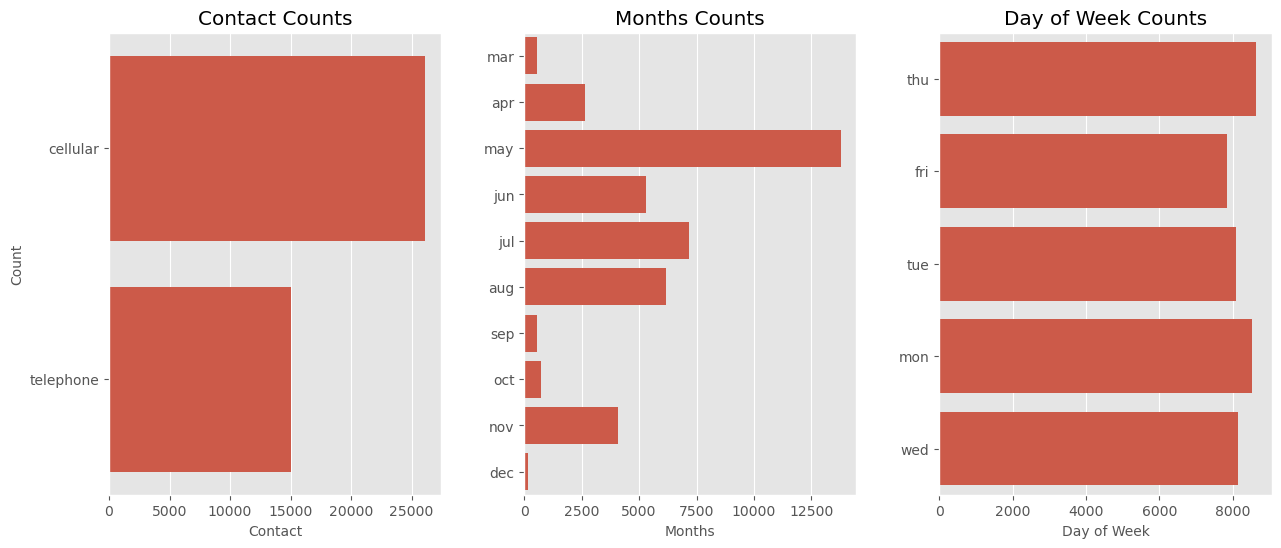

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3, figsize = (15,6))
sns.countplot(credit['contact'], ax = ax1)
ax1.set_xlabel('Contact', fontsize = 10)
ax1.set_ylabel('Count', fontsize = 10)
ax1.set_title('Contact Counts')
ax1.tick_params(labelsize=10)

sns.countplot(credit['month'], ax = ax2, order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])
ax2.set_xlabel('Months', fontsize = 10)
ax2.set_ylabel('')
ax2.set_title('Months Counts')
ax2.tick_params(labelsize=10)

sns.countplot(credit['day_of_week'], ax = ax3)
ax3.set_xlabel('Day of Week', fontsize = 10)
ax3.set_ylabel('')
ax3.set_title('Day of Week Counts')
ax3.tick_params(labelsize=10)

plt.subplots_adjust(wspace=0.25)

Bloque Contacto (Contact): La barra de cellular (móvil) es casi el doble de larga que la de telephone (fijo), con unos 26,000 registros frente a 15,000. La estrategia de contacto es moderna o prioriza los móviles. Al modelar, el tipo de dispositivo podría influir en si la persona contesta o no (la tasa de respuesta suele variar entre fijo y móvil).

Bloque Meses (Months - Estacionalidad): Hay un pico gigante en Mayo (may), que supera por mucho a cualquier otro mes. Los meses de verano (jul, aug, jun) tienen actividad media, mientras que dec, sep, oct y mar son casi nulos. Los datos tienen un sesgo temporal extremo. No es una muestra aleatoria de todo el año; refleja probablemente una campaña masiva específica que ocurrió en mayo.

Bloque Día de la Semana (Day of Week): Todas las barras (mon a fri) son casi idénticas en longitud (alrededor de 8,000 cada una). Es probable que esta variable tenga poco poder predictivo

#### 2.8 VARIABLES INDIVIDUALES 

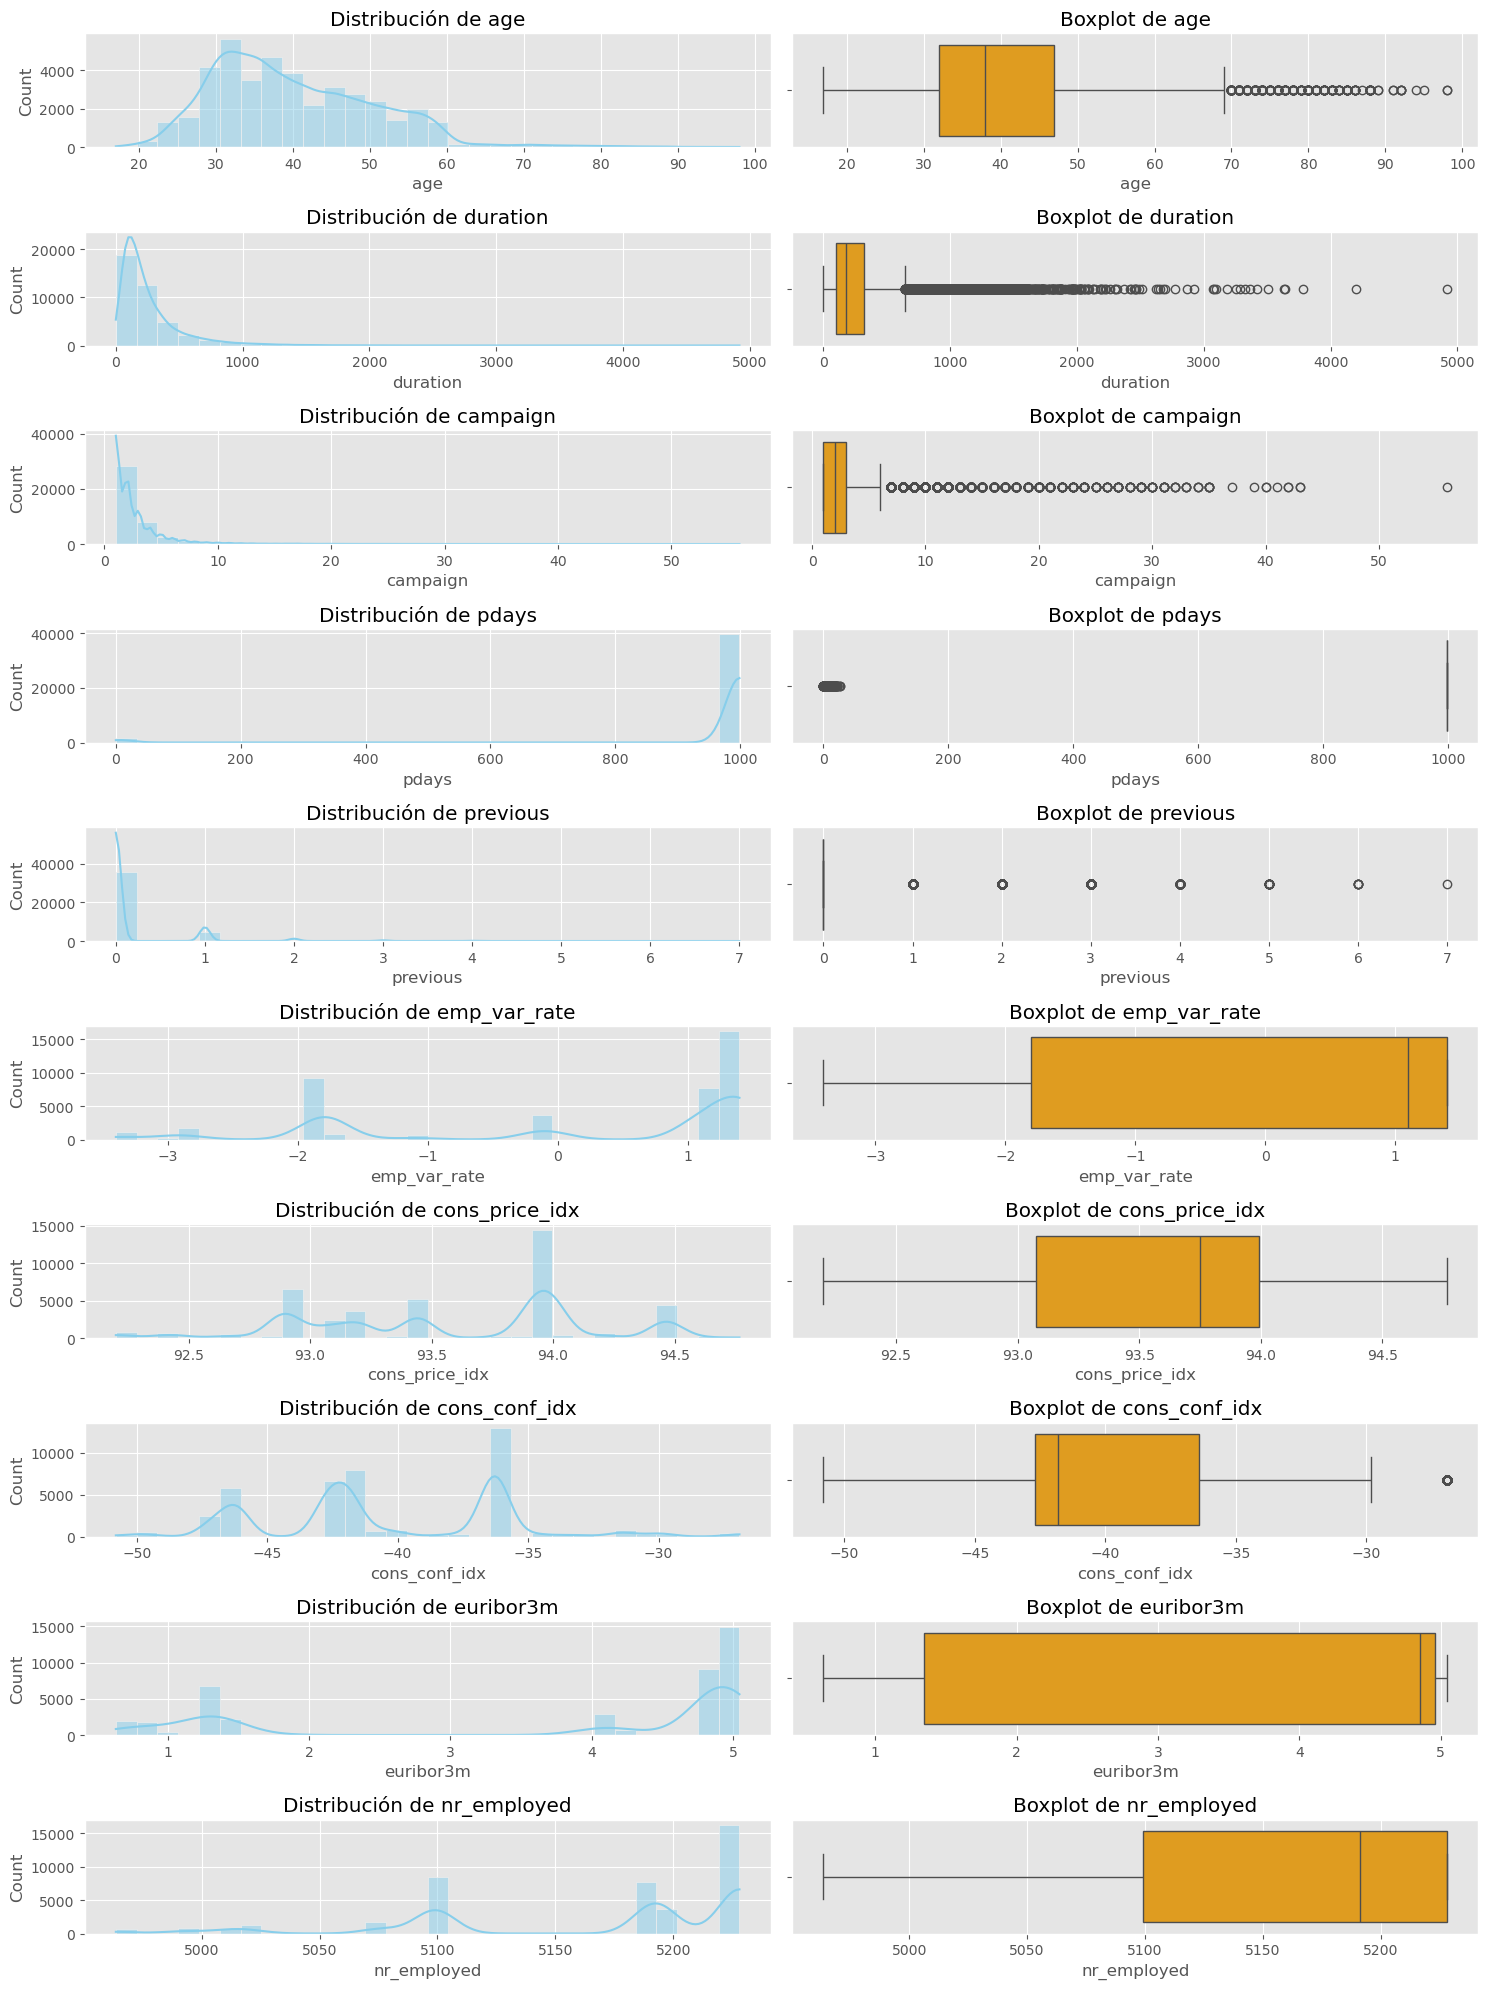

In [25]:
# Definimos las columnas numéricas (excluyendo la target)
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 
            'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']

# Configuración de gráficos
plt.figure(figsize=(15, 20))

for i, col in enumerate(num_cols):
    # Histograma
    plt.subplot(len(num_cols), 2, 2*i + 1)
    sns.histplot(credit[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribución de {col}')
    
    # Boxplot (para ver outliers)
    plt.subplot(len(num_cols), 2, 2*i + 2)
    sns.boxplot(x=credit[col], color='orange')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

1. Perfil de Edad (age) Observo que la gran mayoría de los clientes se concentra en el rango de los 30 a 40 años, que constituye mi población económicamente más activa. El boxplot revela una cantidad significativa de outliers por encima de los 70 años, esto sugiere que los jubilados son casos atípicos en la muestra y podrían comportarse de manera muy distinta al resto.

2. Contacto Previo (pdays) El histograma de pdays es muy revelador: casi la totalidad de los datos se agrupan en el valor 999.999 significa que no ha sido contactado anteriormente

3. Indicadores Económicos (euribor3m, nr_employed, emp_var_rate) Al analizar las variables macroeconómicas, no veo curvas suaves, sino distribuciones con picos muy marcados y separados. Esto indica que los datos no fueron recolectados de manera uniforme a lo largo del tiempo, sino que reflejan momentos muy específicos de la situación económica (probablemente campañas puntuales).

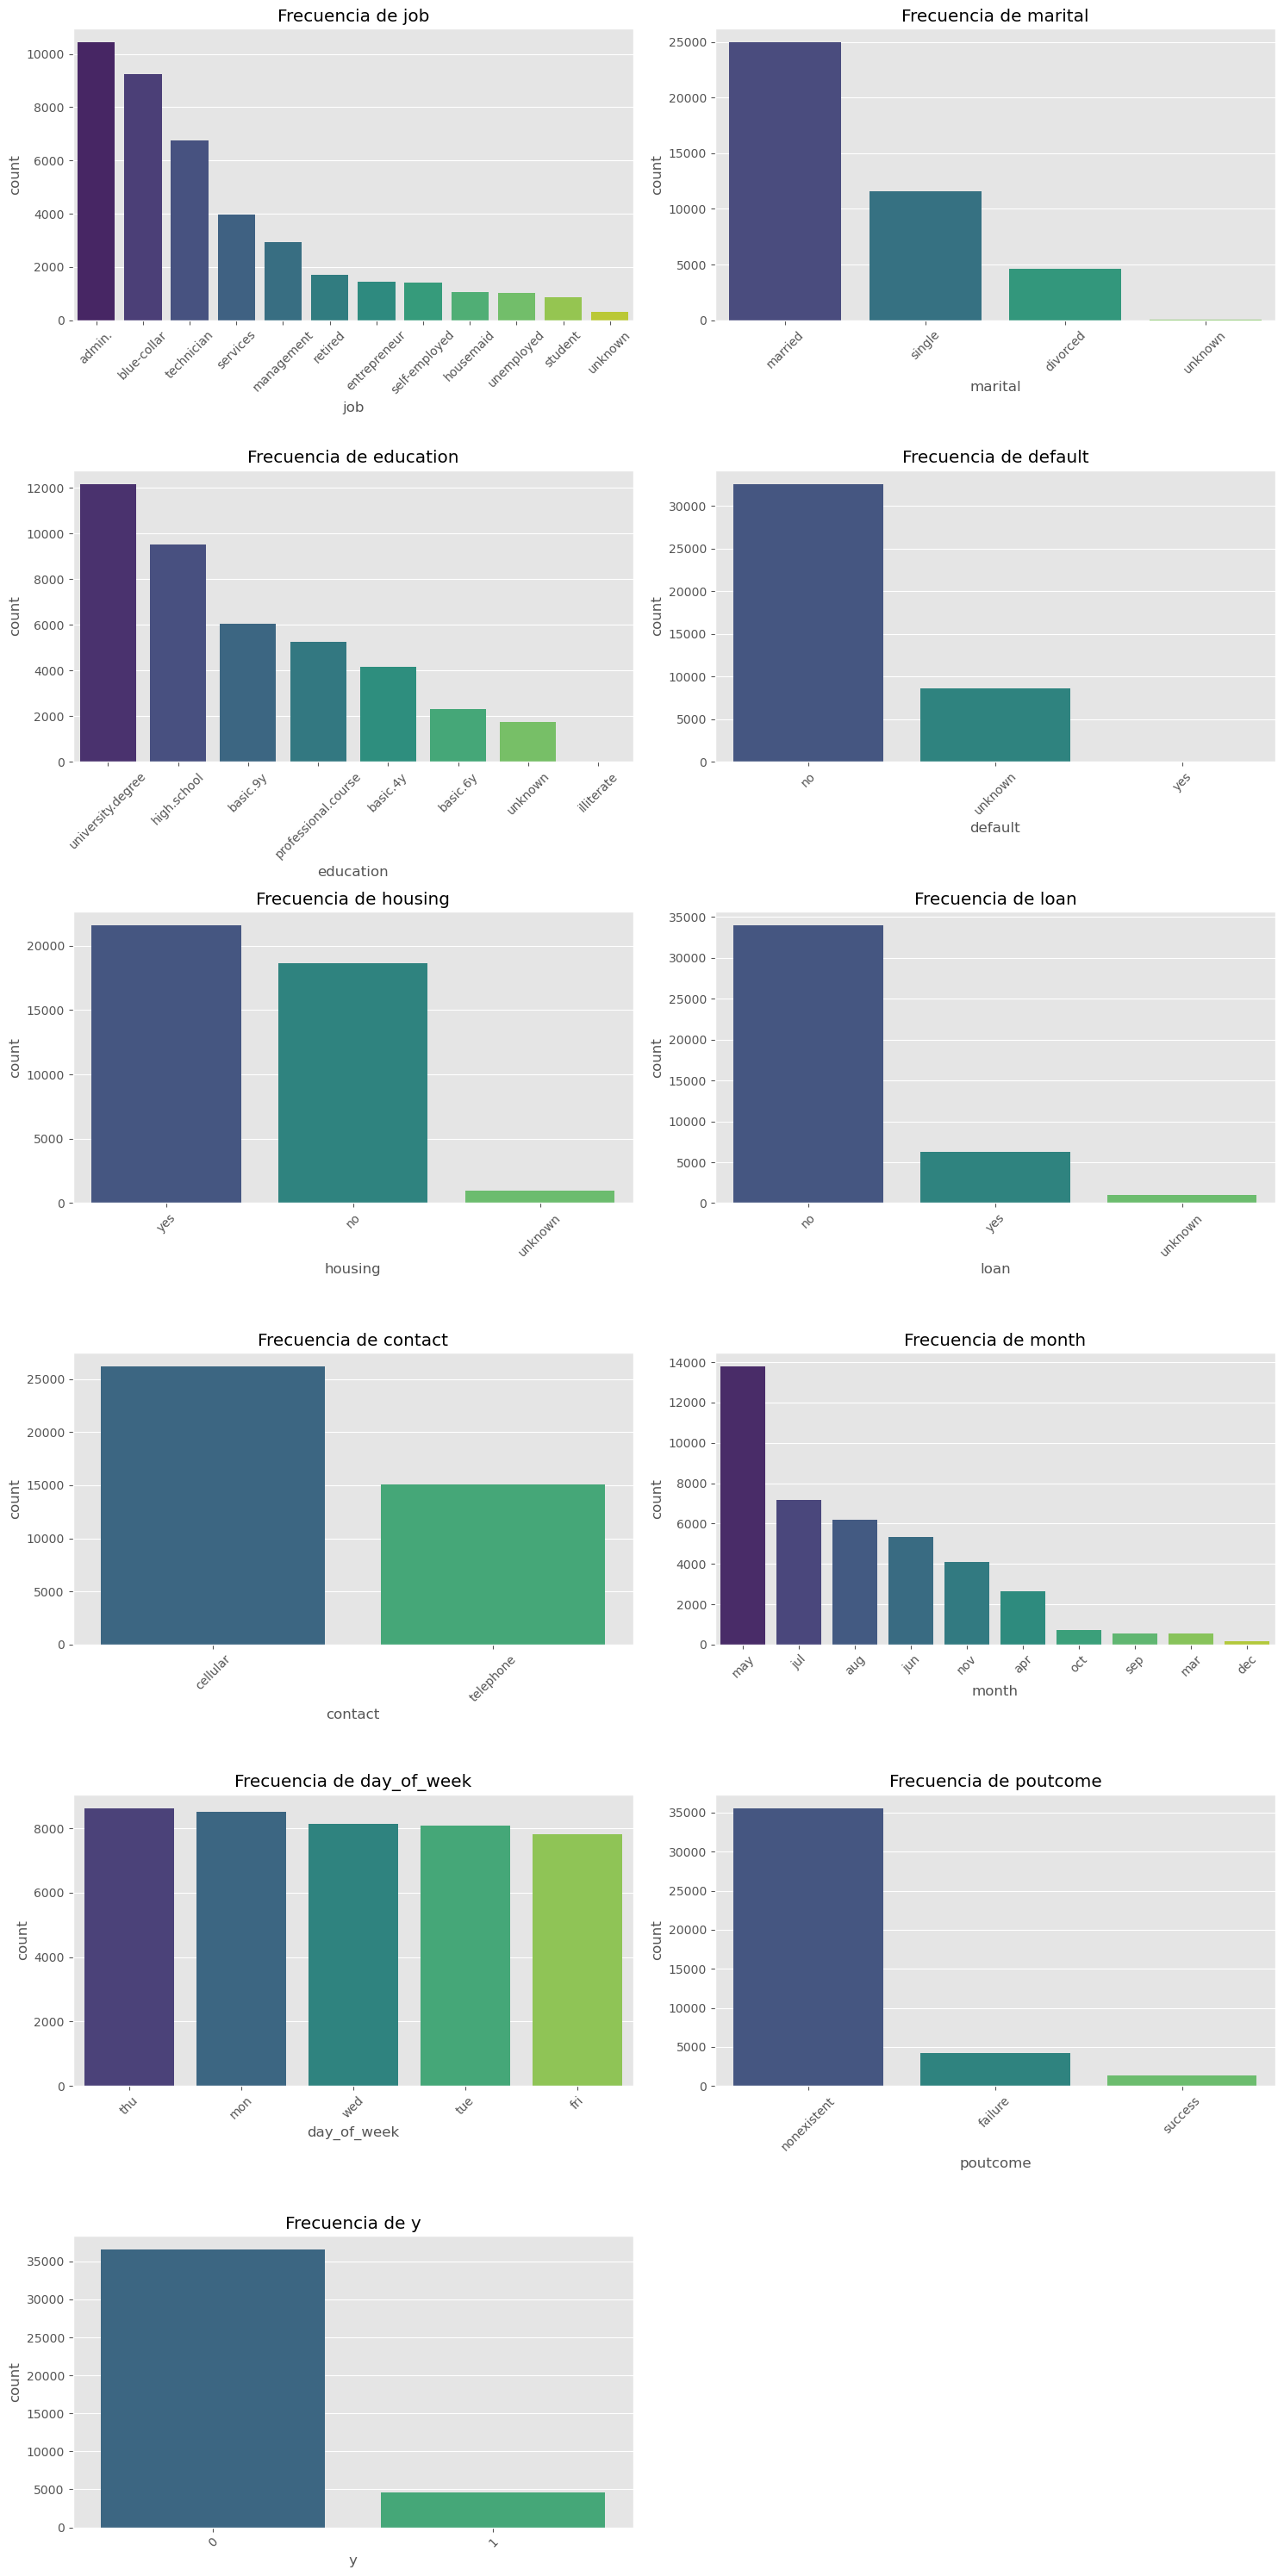

In [26]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
            'contact', 'month', 'day_of_week', 'poutcome', 'y']

plt.figure(figsize=(15, 30))

for i, col in enumerate(cat_cols):
    plt.subplot(6, 2, i + 1)
    # Ordenamos por conteo para verlo mejor
    sns.countplot(x=credit[col], order=credit[col].value_counts().index, palette='viridis')
    plt.title(f'Frecuencia de {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Perfil del Cliente: Predomina un perfil conservador y estable: personas casadas, con trabajo administrativo y educación superior.

Calidad de Variables: La variable default es prácticamente inútil porque casi no tiene variación (casi nadie tiene impagos), mientras que housing (hipoteca) es la más equilibrada y útil para separar grupos.

Sesgo Temporal: Hay un problema de estacionalidad: la mayoría de los datos son de mayo, lo que sesga la muestra. Por el contrario, el día de la semana es irrelevante (distribución plana).

Target Desbalanceado: La variable objetivo y tiene muchísimos más "no" que "sí". Esto confirma que tendré que usar técnicas de balanceo o métricas específicas (como Recall) en lugar de solo mirar la exactitud (Accuracy).

#### 2.9 Relaciones entre variables

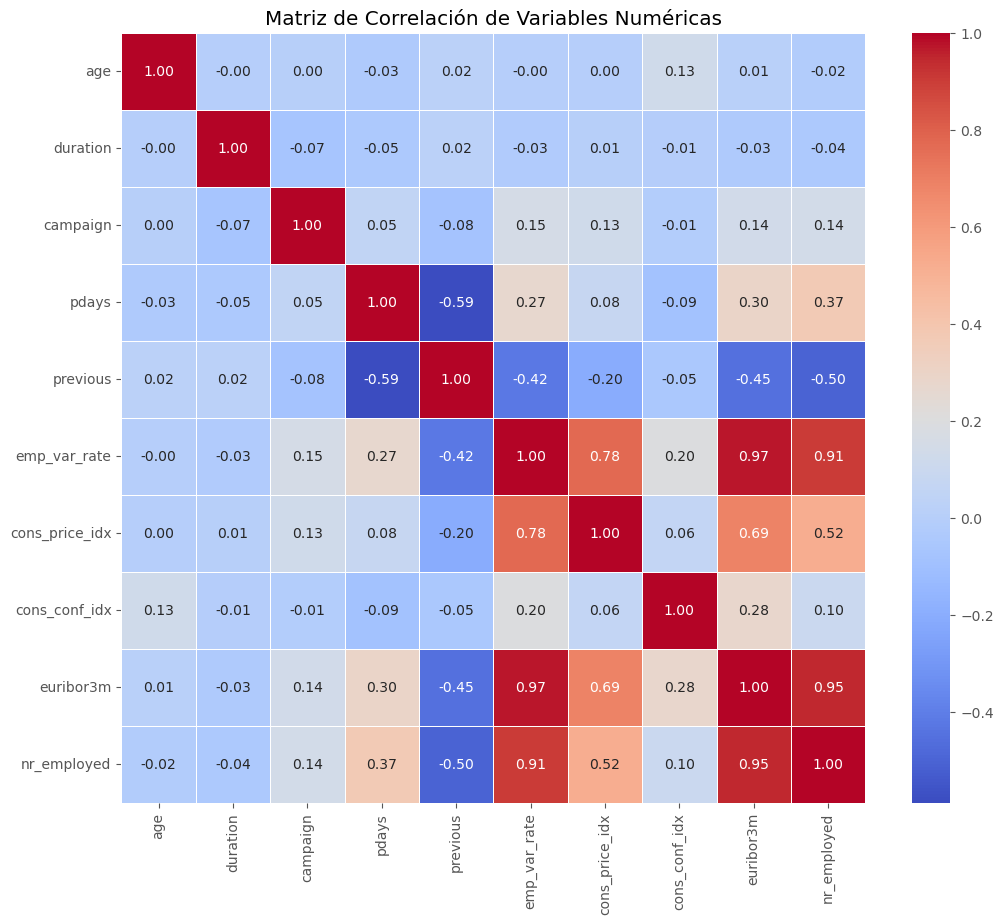

In [27]:
# Calculamos la correlación solo de las columnas numéricas
plt.figure(figsize=(12, 10))
corr_matrix = credit[num_cols].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

Alerta de Multicolinealidad (Bloque Rojo Inferior): He notado que las variables económicas (emp_var_rate, euribor3m y nr_employed) están extremadamente correlacionadas entre sí (valores de 0.95 a 0.97).

Relación Histórica (pdays vs previous): Existe una correlación negativa fuerte (-0.59) entre estas dos. Es lógico: si ya hubo contactos previos (previous), la variable de días (pdays) deja de ser 999. Esto confirma que ambas miden la "temperatura" de la relación con el cliente.

Independencia de la Edad y Duración: Me llama la atención que age y duration tienen colores muy claros (correlación casi 0) con el resto. Son variables muy "independientes", lo cual es bueno porque aportan información única que no se solapa con los datos económicos.

In [28]:
print('Impago de crédito:'
      '\n No tiene impago:'          , credit[credit['default'] == 'no']     ['age'].count(),
      '\n Impago desconocido:'       , credit[credit['default'] == 'unknown']['age'].count(),
      '\n Sí tiene impago:'          , credit[credit['default'] == 'yes']    ['age'].count())


Impago de crédito:
 No tiene impago: 32588 
 Impago desconocido: 8597 
 Sí tiene impago: 3


In [29]:
print('Préstamo hipotecario:'
      '\n No tiene préstamo:'           , credit[credit['housing'] == 'no']['age'].count(),
      '\n Préstamo desconocido:'        , credit[credit['housing'] == 'unknown']['age'].count(),
      '\n Sí tiene préstamo:'           , credit[credit['housing'] == 'yes']['age'].count())


Préstamo hipotecario:
 No tiene préstamo: 18622 
 Préstamo desconocido: 990 
 Sí tiene préstamo: 21576


In [30]:
print('Préstamo personal:'
      '\n No tiene préstamo:'     , credit[credit['loan'] == 'no']['age'].count(),
      '\n Préstamo desconocido:'        , credit[credit['loan'] == 'unknown']['age'].count(),
      '\n Sí tiene préstamo:'           , credit[credit['loan'] == 'yes']['age'].count())


Préstamo personal:
 No tiene préstamo: 33950 
 Préstamo desconocido: 990 
 Sí tiene préstamo: 6248


## 3. Preprocessing data


#### 3.1 Bank Client Categorical Treatment
- Jobs, Marital, Education, Default, Housing, Loan. Converting to continuous due the feature scaling will be apllyed later

In [31]:
# Education tiene un orden lógico, lo convertimos manualmente
education_mapping = {
    'illiterate': 1,
    'basic.4y': 2,
    'basic.6y': 3,
    'basic.9y': 4,
    'high.school': 5,
    'professional.course': 6,
    'university.degree': 7,
    'unknown': 8
}
#--------------------------Preparacion train-------------------------
credit['education'] = credit['education'].map(education_mapping)
#--------------------------Preparacion test--------------------------
credit_test['education'] = credit_test['education'].map(education_mapping)

In [32]:
labelencoder_X = LabelEncoder()
#--------------------------Preparacion train-------------------------
credit['job']      = labelencoder_X.fit_transform(credit['job']) 
credit['marital']  = labelencoder_X.fit_transform(credit['marital']) 
credit['education']= labelencoder_X.fit_transform(credit['education']) 
credit['default']  = labelencoder_X.fit_transform(credit['default']) 
credit['housing']  = labelencoder_X.fit_transform(credit['housing']) 
credit['loan']     = labelencoder_X.fit_transform(credit['loan']) 
credit['poutcome'] = labelencoder_X.fit_transform(credit['poutcome']) 

#--------------------------Preparacion test--------------------------
credit_test['job']      = labelencoder_X.fit_transform(credit_test['job']) 
credit_test['marital']  = labelencoder_X.fit_transform(credit_test['marital']) 
credit_test['education']= labelencoder_X.fit_transform(credit_test['education']) 
credit_test['default']  = labelencoder_X.fit_transform(credit_test['default']) 
credit_test['housing']  = labelencoder_X.fit_transform(credit_test['housing']) 
credit_test['loan']     = labelencoder_X.fit_transform(credit_test['loan']) 
credit_test['poutcome'] = labelencoder_X.fit_transform(credit_test['poutcome']) 

In [33]:
credit_cat = credit.iloc[:, list(range(0,7)) + [14]]

In [34]:
print(credit.shape)
credit_cat.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,poutcome
0,44,1,1,1,1,2,0,1
1,53,9,1,7,0,0,0,1
2,28,4,2,6,0,2,0,2
3,39,7,1,4,0,0,0,1
4,55,5,1,1,0,2,0,2


#### 3.2 Related with the last contact of the current campaign
- Treat categorical, see those values
- group continuous variables if necessary


In [35]:
from sklearn.preprocessing import LabelEncoder

labelencoder_X = LabelEncoder()
#--------------------------Preparacion train--------------------------
credit['contact']     = labelencoder_X.fit_transform(credit['contact'])
credit['month']       = labelencoder_X.fit_transform(credit['month'])
credit['day_of_week'] = labelencoder_X.fit_transform(credit['day_of_week'])

#--------------------------Preparacion test--------------------------
credit_test['contact']     = labelencoder_X.fit_transform(credit_test['contact'])
credit_test['month']       = labelencoder_X.fit_transform(credit_test['month'])
credit_test['day_of_week'] = labelencoder_X.fit_transform(credit_test['day_of_week'])

In [36]:
credit_temp = credit.iloc[: , 7:11]
credit_temp.head()

,contact,month,day_of_week,duration
0,0,1,2,210
1,0,7,0,138
2,0,4,2,339
3,0,0,0,185
4,0,1,0,137


In [37]:
credit.isnull().any()

age               False
job               False
marital           False
education         False
default           False
housing           False
loan              False
contact           False
month             False
day_of_week       False
duration          False
campaign          False
pdays             False
previous          False
poutcome          False
emp_var_rate      False
cons_price_idx    False
cons_conf_idx     False
euribor3m         False
nr_employed       False
y                 False
dtype: bool

In [38]:
credit_test.isnull().any()

age               False
job               False
marital           False
education         False
default           False
housing           False
loan              False
contact           False
month             False
day_of_week       False
duration          False
campaign          False
pdays             False
previous          False
poutcome          False
emp_var_rate      False
cons_price_idx    False
cons_conf_idx     False
euribor3m         False
nr_employed       False
dtype: bool

In [39]:
print("Tipo de contacto: \n", credit['contact'].unique())
print("\nEn qué meses se realizó esta campaña: \n", credit['month'].unique())
print("\nQué días de la semana se realizó esta campaña: \n", credit['day_of_week'].unique())

Tipo de contacto: 
 [0 1]

En qué meses se realizó esta campaña: 
 [1 7 4 0 3 6 8 5 9 2]

Qué días de la semana se realizó esta campaña: 
 [2 0 3 1 4]


3.3 Borrar variables

In [40]:
cols_to_drop = [
    'duration',       # Data Leakage
    'default',        # Sin varianza útil
    'nr_employed',    # Multicolinealidad extrema
    'emp_var_rate',   # Multicolinealidad extrema
    'day_of_week',    # Irrelevancia estadística
    'pdays'           # Reemplazada por 'was_contacted'
]

# Eliminamos las columnas del train
credit = credit.drop(columns=cols_to_drop, axis=1)

# Eliminamos las columnas del test
credit_test = credit_test.drop(columns=cols_to_drop, axis=1)

## 4. Creación del modelo y división del dataset

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definición de X e y
X = credit.drop('y', axis=1)
y = credit['y']

In [42]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

El conjunto de datos se divide en entrenamiento y prueba para evaluar el rendimiento del modelo sobre datos no vistos y evitar sobreajuste.

In [43]:
print("Training set shape", X_train.shape)
print("Test set shape", X_test.shape)

Training set shape (32950, 14)
Test set shape (8238, 14)


### 5. Entrenamiento 

#### knn

calculo de la mejor k

([<matplotlib.axis.XTick at 0x7fff582e4c90>,
 [Text(0, 0, '0'), Text(5, 0, '5'), Text(10, 0, '10'), Text(15, 0, '15')])

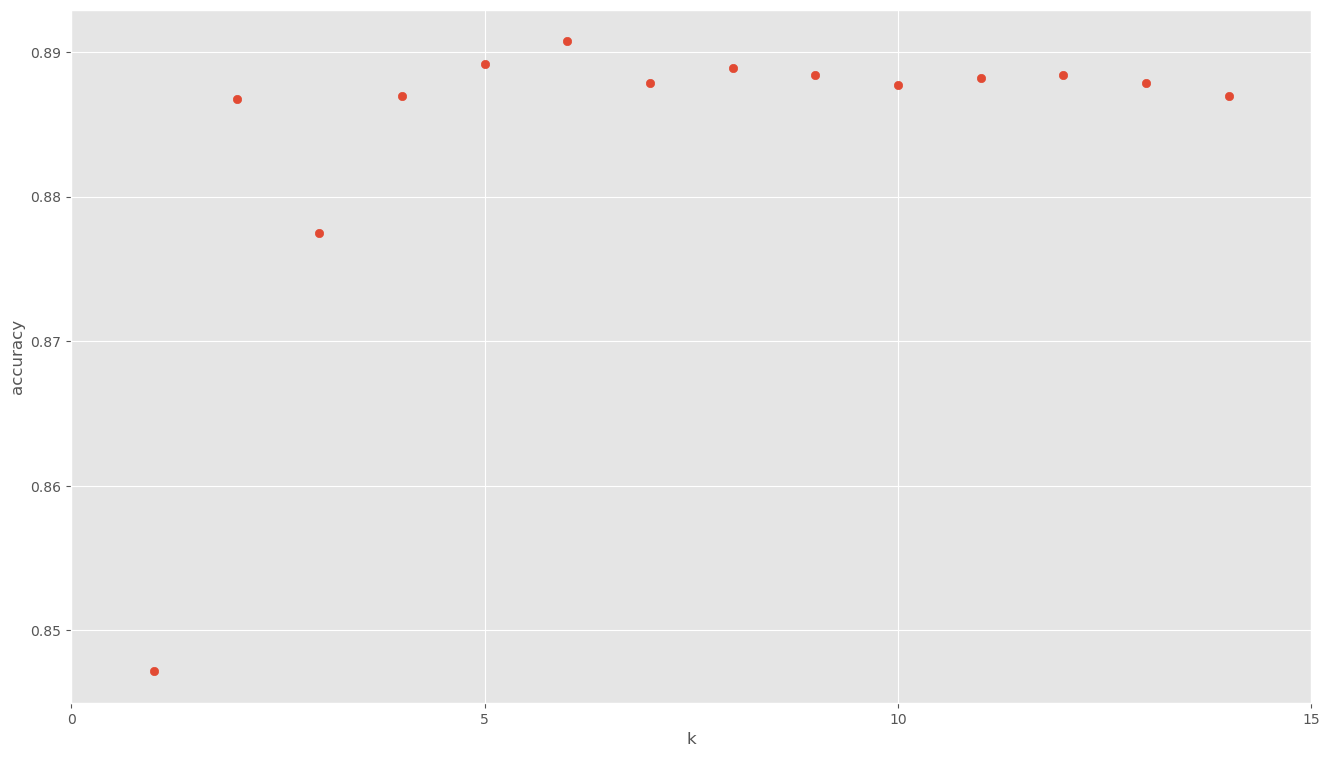

In [44]:
k_range = range(1, 15)
scores = []
for k in k_range:
      knn = KNeighborsClassifier(n_neighbors = k)
      knn.fit(X_train, y_train)
      scores.append(knn.score(X_test, y_test))
plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')
plt.scatter(k_range, scores)
plt.xticks([0,5,10,15])

In [45]:
n_neighbors = 6 # busca los 6 mas cercanos

knn = KNeighborsClassifier(n_neighbors)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=6)

#### LogisticRegression

In [46]:
clf = LogisticRegression(class_weight='balanced', random_state=42)

In [47]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

#### Decison Tree

Creación del modelo de Árboles de decisión

In [48]:
tree_clf = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

In [49]:
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

## 6. Análisis de resultados

#### Knn

In [50]:
print('Accuracy of K-NN classifier on training set: {:.2f}'
      .format(knn.score(X_train, y_train)))#dice el resultado de el entreanmiento de knn
print('Accuracy of K-NN classifier on test set: {:.2f}'
      .format(knn.score(X_test, y_test)))#dice el resultado de el test de knn, si es ligeramente menor es que es bueno. si es malo tiene overfiting

Accuracy of K-NN classifier on training set: 0.91
Accuracy of K-NN classifier on test set: 0.89


#### LogisticRegression

In [51]:
# Umbral para la decisión
prob_th = 0.7
prob_df=pd.DataFrame(clf.predict_proba(X_test[:10]),columns=['Prob of NO','Prob of YES'])
prob_df['Decision']=(prob_df['Prob of YES']>prob_th).apply(int)
prob_df

,Prob of NO,Prob of YES,Decision
0,0.599448,0.400552,0
1,0.798288,0.201712,0
2,0.655433,0.344567,0
3,0.707735,0.292265,0
4,0.391703,0.608297,0
5,0.250025,0.749975,1
6,0.585507,0.414493,0
7,0.301364,0.698636,0
8,0.223421,0.776579,1
9,0.765401,0.234599,0


In [52]:
print('Accuracy of Logistic Regresion classifier on training set: {:.2f}'
      .format(clf.score(X_train, y_train)))#dice el resultado de el entreanmiento de knn
print('Accuracy of Logistic Regresion classifier on test set: {:.2f}'
      .format(clf.score(X_test, y_test)))#dice el resultado de el test de knn, si es ligeramente menor es que es bueno. si es malo tiene overfiting

Accuracy of Logistic Regresion classifier on training set: 0.75
Accuracy of Logistic Regresion classifier on test set: 0.75


#### Decision Tree

In [53]:
# Umbral para la decisión
prob_th = 0.7
prob_df=pd.DataFrame(tree_clf.predict_proba(X_test[:10]),columns=['Prob of NO','Prob of YES'])
prob_df['Decision']=(prob_df['Prob of YES']>prob_th).apply(int)
prob_df

,Prob of NO,Prob of YES,Decision
0,0.656780,0.343220,0
1,0.697473,0.302527,0
2,0.656780,0.343220,0
3,0.627857,0.372143,0
4,0.600949,0.399051,0
5,0.147489,0.852511,1
6,0.656780,0.343220,0
7,0.349763,0.650237,0
8,0.349763,0.650237,0
9,0.828943,0.171057,0


In [54]:
print('Accuracy of Decision tree classifier on training set: {:.2f}'
      .format(tree_clf.score(X_train, y_train)))#dice el resultado de el entreanmiento de knn
print('Accuracy of Decision tree classifier on test set: {:.2f}'
      .format(tree_clf.score(X_test, y_test)))#dice el resultado de el test de knn, si es ligeramente menor es que es bueno. si es malo tiene overfiting

Accuracy of Decision tree classifier on training set: 0.83
Accuracy of Decision tree classifier on test set: 0.83


## 7. Realización de predicciones

#### Knn

In [55]:
pred = knn.predict(X_test)
print(confusion_matrix(y_test, pred)) #matriz de confusion de lo que predijo y de lo que debia predecir

[[7181  129]
 [ 771  157]]


In [56]:
print(classification_report(y_test, knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7310
           1       0.55      0.17      0.26       928

    accuracy                           0.89      8238
   macro avg       0.73      0.58      0.60      8238
weighted avg       0.86      0.89      0.86      8238



In [57]:
print('Score: {}'.format(knn.score(X_test, y_test)))

Score: 0.8907501820830298


#### LogisticRegression

In [58]:
print(confusion_matrix(y_test, (clf.predict_proba(X_test)[:, 1] >= 0.6).astype(int))) # si la probabilidad es mayor a a 0.6 devuelve True o False.

[[6031 1279]
 [ 353  575]]


In [59]:
print(classification_report(y_test, (clf.predict_proba(X_test)[:, 1] >= 0.6).astype(int)))

              precision    recall  f1-score   support

           0       0.94      0.83      0.88      7310
           1       0.31      0.62      0.41       928

    accuracy                           0.80      8238
   macro avg       0.63      0.72      0.65      8238
weighted avg       0.87      0.80      0.83      8238



In [60]:
print('Score: {}'.format(clf.score(X_test, y_test)))

Score: 0.7537023549405195


#### Decision Tree

In [61]:
print(confusion_matrix(y_test, (tree_clf.predict_proba(X_test)[:, 1] >= 0.7).astype(int))) # si la probabilidad es mayor a a 0.7 devuelve True o False.

[[6729  581]
 [ 457  471]]


In [62]:
print(classification_report(y_test, (tree_clf.predict_proba(X_test)[:, 1] >= 0.7).astype(int)))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7310
           1       0.45      0.51      0.48       928

    accuracy                           0.87      8238
   macro avg       0.69      0.71      0.70      8238
weighted avg       0.88      0.87      0.88      8238



In [63]:
print('Score: {}'.format(tree_clf.score(X_test, y_test)))

Score: 0.8278708424374849


1. K-Nearest Neighbors (KNN)

        Accuracy (0.89): Engañosamente alta debido a la clase mayoritaria (0).

        Recall (0.17): Críticamente bajo. El modelo solo clasificó correctamente al 17% de los casos positivos reales.

        F1-Score (0.26): El rendimiento global para la clase de interés es deficiente.

    El modelo sufre un sesgo severo hacia la clase mayoritaria, fallando en la tarea principal de identificación.

2. Regresión Logística (Threshold Ajustado 0.6)

        Recall (0.62): Mejora drástica respecto al KNN, detectando al 62% de los casos positivos.

        Precision (0.31): Muy baja. De todas las predicciones positivas realizadas, solo el 31% fueron correctas. Esto indica una alta tasa de Falsos Positivos.

        F1-Score (0.41): Mejora respecto al KNN, pero penalizado por la falta de precisión.

3. Decision Tree (Threshold Ajustado 0.7) - Modelo Seleccionado

        Recall (0.51): Mantiene una sensibilidad competente, recuperando más de la mitad de los casos positivos del dataset.

        Precision (0.45): Superior a la Regresión Logística. El modelo es más selectivo y fiable cuando predice un "1".

        F1-Score (0.48): El valor más alto de los tres modelos. 


    Al maximizar el F1-Score, este modelo ofrece la mejor relación armónica entre capacidad de detección (Recall) y confiabilidad de la predicción (Precision).

    Por lo que elegire este modelo

In [74]:
probas = tree_clf.predict_proba(credit_test)[:, 1]
predicciones = (probas >= 0.7).astype(int)
predicciones

array([0, 0, 0, ..., 0, 0, 0])

In [75]:
pd.Series(predicciones).value_counts()

0    3672
1     447
Name: count, dtype: int64

## 8. Visualización

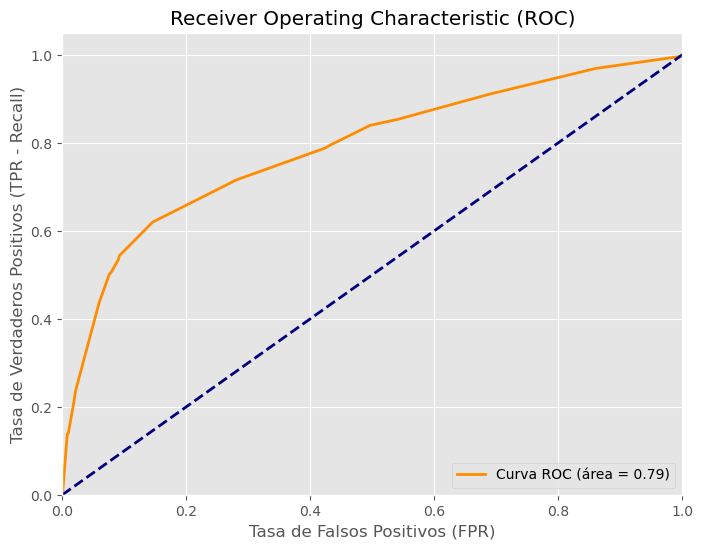

In [76]:
# Curva ROC
from sklearn.metrics import roc_curve, auc

# Obtener probabilidades de la clase positiva (1)
y_probs = tree_clf.predict_proba(X_test)[:, 1]

# Calcular puntos para la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Gráfica
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea base aleatoria
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR - Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

La Curva ROC confirma que el modelo tiene capacidad predictiva superior al azar (AUC > 0.7). 

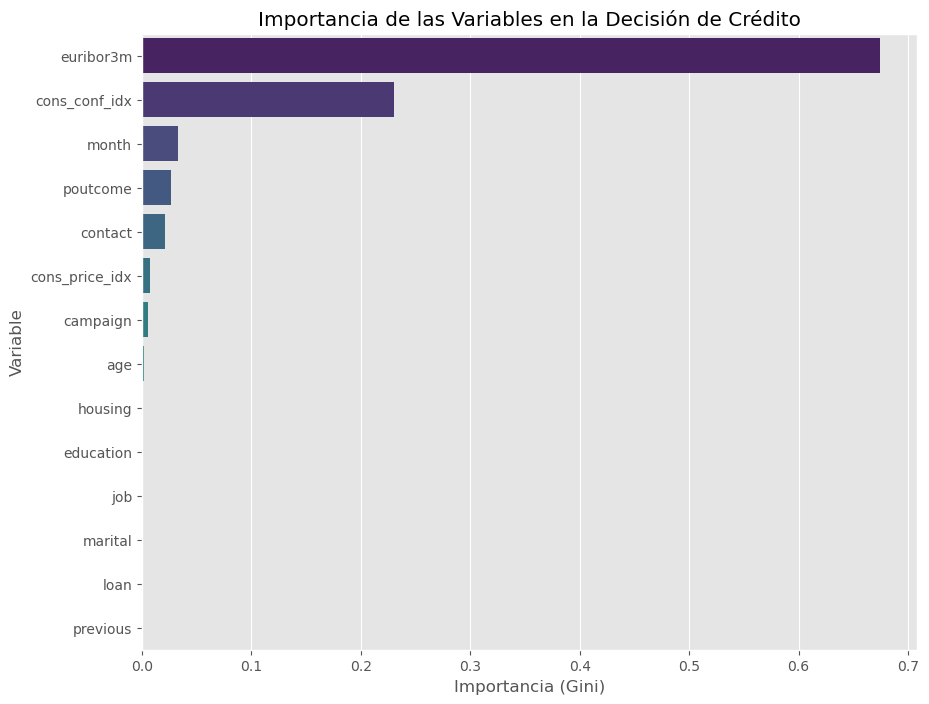

In [77]:
feature_names = X.columns 

importances = tree_clf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Gráfica de barras
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Importancia de las Variables en la Decisión de Crédito')
plt.xlabel('Importancia (Gini)')
plt.ylabel('Variable')
plt.show()

En laa gráfica se ve q las variables económicas (Euribor) son determinantes, lo cual sugiere que la concesión del crédito depende más del contexto económico que del perfil individual.

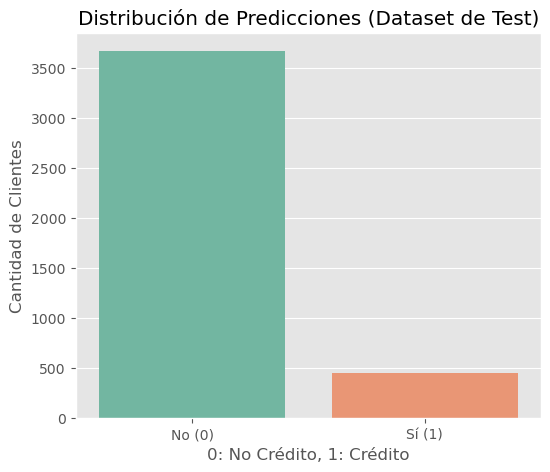

In [80]:
# Distribución de Predicciones Finales
plt.figure(figsize=(6, 5))
# Usamos 'predicciones' que definiste anteriormente
sns.countplot(x=predicciones, palette='Set2')
plt.title('Distribución de Predicciones (Dataset de Test)')
plt.xlabel('0: No Crédito, 1: Crédito')
plt.ylabel('Cantidad de Clientes')
plt.xticks(ticks=[0, 1], labels=['No (0)', 'Sí (1)'])
plt.show()

Ante la duda, el modelo dice NO. Para que la barra naranja suba, el modelo tiene que estar muy seguro. No se la juega.

## 9. Conclusiones

El modelo prefiere dejar pasar una buena oportunidad (Falso Negativo) antes que aceptar un mal cliente o una mala operación (Falso Positivo). Espera pacientemente a que se cumplan condiciones muy específicas para dar la señal de "Sí". Esto concluye que el sistema está optimizado para la calidad sobre la cantidad. Esto es ideal para escenarios donde el coste del error es alto (impagos en crédito)